In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/superstore_raw.csv")

print("First 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
1       2  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
2       3  CA-2016-138688  06-12-2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   consumer  United States        HENDERSON  ...   
1      Claire Gute   CONSUMER  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      LOS ANGELES  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Cat

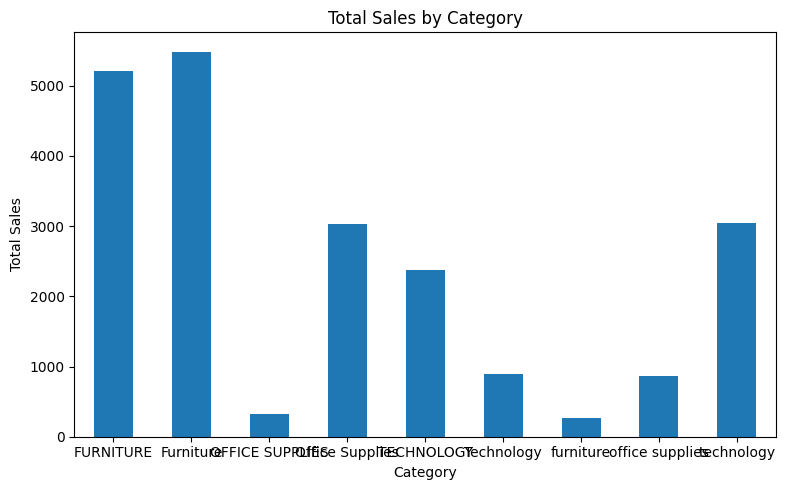

In [3]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

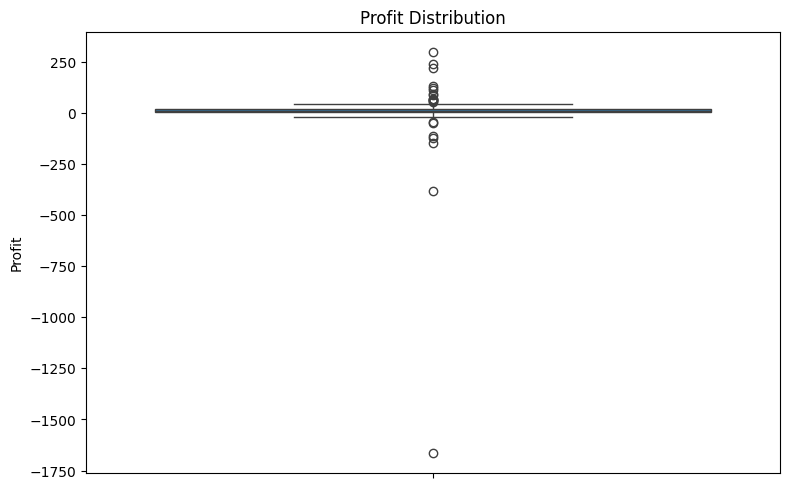

In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["Profit"])
plt.title("Profit Distribution")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

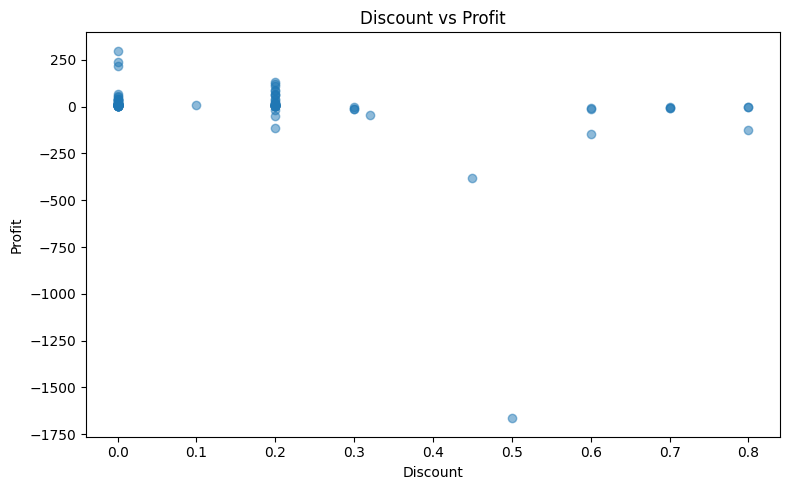

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [6]:
numerical_columns = df.select_dtypes(include="number")

correlation_matrix = numerical_columns.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
               Row ID  Postal Code     Sales  Quantity  Discount    Profit
Row ID       1.000000    -0.090782 -0.250134 -0.119111 -0.108007  0.068553
Postal Code -0.090782     1.000000 -0.016381  0.027921  0.080849  0.139706
Sales       -0.250134    -0.016381  1.000000  0.412793  0.122386 -0.542119
Quantity    -0.119111     0.027921  0.412793  1.000000  0.100989 -0.126887
Discount    -0.108007     0.080849  0.122386  0.100989  1.000000 -0.283765
Profit       0.068553     0.139706 -0.542119 -0.126887 -0.283765  1.000000


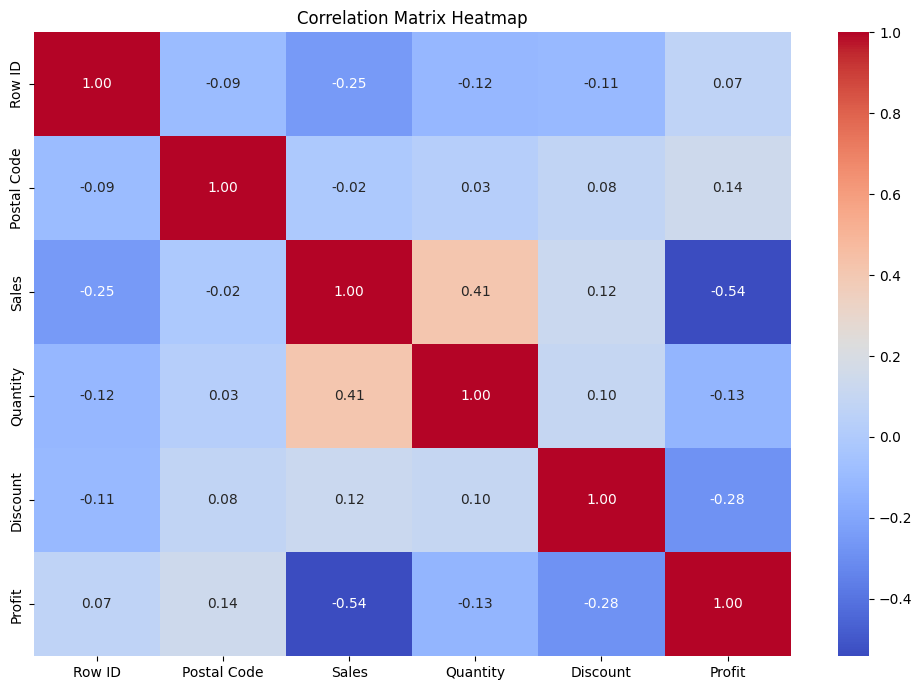

In [7]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()


In [9]:
category_profit = df.groupby("Category")["Profit"].sum()

highest_profit_category = category_profit.idxmax()
highest_profit = category_profit.max()

print(category_profit)

print(highest_profit_category)

print("Highest total profit:", highest_profit)

Category
FURNITURE           430.6715
Furniture         -2149.9990
OFFICE SUPPLIES      68.4298
Office Supplies     365.2392
TECHNOLOGY          432.6319
Technology          171.7022
furniture            41.9136
office supplies     238.2503
technology          299.2698
Name: Profit, dtype: float64
TECHNOLOGY
Highest total profit: 432.63190000000003


In [ ]:
highest_sales_category = category_sales.idxmax()
highest_sales = category_sales.max()


print("1. The", highest_sales_category,
      "category has the highest total sales.")

print("2. The", highest_profit_category,
      "category has the highest total profit.")

print("3. The scatter plot shows the relationship between discount and profit. "
      "Higher discounts can be associated with lower or negative profits in some cases.")


Business Insights:
1. The Furniture category has the highest total sales.
2. The TECHNOLOGY category has the highest total profit.
3. The scatter plot shows the relationship between discount and profit. Higher discounts can be associated with lower or negative profits in some cases.
